# OpenTouch Dataset Exploration
## 6.S985 Project — Direction B: Pre-Contact Intent Prediction from Gaze and Trajectory

This notebook provides structured exploration of the OpenTouch dataset with a focus on Direction B:
predicting grasp intent from pre-contact egocentric video and hand trajectory — before touch occurs.

### HDF5 Structure (confirmed)
```
file.hdf5
└── data/
    ├── demo_00/
    │   ├── rgb_images_jpeg       (T,)        JPEG-encoded bytes
    │   ├── right_pressure        (T, 16, 16) tactile pressure map
    │   ├── right_hand_landmarks  (T, 21, 3)  full hand joints
    │   ├── right_palm_pos        (T, 3)      palm position
    │   ├── right_wrist_pos       (T, 3)      wrist position
    │   ├── camera_poses          (T, 4, 4)   extrinsic camera pose
    │   └── timestamps            (T,)        unix timestamps
    ├── demo_01/ ...
    └── ...
```

### Contents
1. Imports & paths
2. Dataset inventory
3. Annotations loading
4. Modality visualization
5. Contact onset detection
6. Pre-contact window extraction
7. Label distributions
8. Pre-contact trajectory analysis
9. Dataset-wide index & train/val/test split

---
## 1. Imports & Paths

In [1]:
import os
import io
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Paths: adjust OPENTOUCH_ROOT to your local clone ──────────────────────
OPENTOUCH_ROOT = Path('/Users/cassandrahe/Documents/6.S985/opentouch')
DATA_DIR        = OPENTOUCH_ROOT / 'data'
ANNOTATIONS_DIR = DATA_DIR / 'final_annotations'

assert DATA_DIR.exists(), f'DATA_DIR not found: {DATA_DIR}'
assert ANNOTATIONS_DIR.exists(), f'ANNOTATIONS_DIR not found: {ANNOTATIONS_DIR}'
print('Paths OK')

Paths OK


---
## 2. Dataset Inventory

In [2]:
hdf5_files = sorted(DATA_DIR.glob('*.hdf5'))
print(f'Found {len(hdf5_files)} HDF5 files\n')

# Each file has a top-level 'data' group containing demo_00, demo_01, ...
file_demo_map = {}  # Path -> list of demo keys
total_clips = 0

for hf in hdf5_files:
    with h5py.File(hf, 'r') as f:
        if 'data' not in f:
            print(f'  WARNING: no data group in {hf.name}')
            continue
        demos = sorted(f['data'].keys())
        file_demo_map[hf] = demos
        total_clips += len(demos)

print(f'{"File":<40} {"Clips":>6}')
print('-' * 48)
for hf, demos in file_demo_map.items():
    print(f'{hf.name:<40} {len(demos):>6}')
print('-' * 48)
print(f'{"Total clips":<40} {total_clips:>6}')

Found 26 HDF5 files

File                                      Clips
------------------------------------------------
eat_mcdonalds.hdf5                           51
eat_ygf_p1.hdf5                              14
eat_ygf_p2.hdf5                              44
fablab_ml_p1.hdf5                            86
fablab_ml_p2.hdf5                            94
fablab_ml_p3.hdf5                            47
grocery_plant.hdf5                           70
grocery_target_p1.hdf5                      134
grocery_target_p2.hdf5                       98
grocery_target_p3.hdf5                      227
grocery_tj.hdf5                              77
hardware_homedepot_p1.hdf5                   29
hardware_homedepot_p2.hdf5                  101
hardware_homedepot_p3.hdf5                  135
hardware_homedepot_p4.hdf5                   95
hardware_homedepot_p5.hdf5                  184
home_bedroom.hdf5                           138
home_kitchen_p1.hdf5                        190
home_kitchen_p2.hd

Clip length (frames) — mean: 110.6, median: 85, min: 17, max: 1381


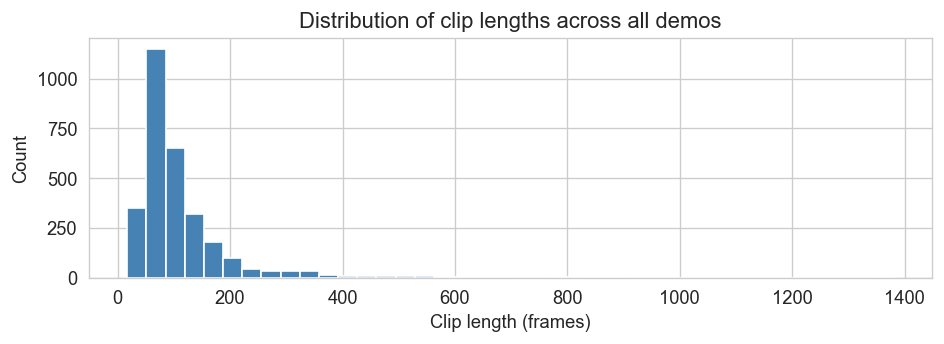

In [3]:
# Clip length distribution
clip_lengths = []
for hf, demos in file_demo_map.items():
    with h5py.File(hf, 'r') as f:
        for demo_id in demos:
            T = f['data'][demo_id]['timestamps'].shape[0]
            clip_lengths.append(T)

clip_lengths = np.array(clip_lengths)
print(f'Clip length (frames) — mean: {clip_lengths.mean():.1f}, '
      f'median: {np.median(clip_lengths):.0f}, '
      f'min: {clip_lengths.min()}, max: {clip_lengths.max()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(clip_lengths, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Clip length (frames)')
ax.set_ylabel('Count')
ax.set_title('Distribution of clip lengths across all demos')
plt.tight_layout()
plt.show()

---
## 3. Annotations

In [4]:
# Inspect what is in the annotations directory
ann_files = list(ANNOTATIONS_DIR.iterdir())
print(f'Files in annotations dir ({len(ann_files)} total):')
for f in sorted(ann_files)[:20]:
    print(f'  {f.name}')
if len(ann_files) > 20:
    print(f'  ... and {len(ann_files) - 20} more')

Files in annotations dir (25 total):
  eat_mcdonalds_merged.csv
  eat_ygf_p1_merged.csv
  eat_ygf_p2_merged.csv
  fablab_ml_p1_merged.csv
  fablab_ml_p2_merged.csv
  fablab_ml_p3_merged.csv
  grocery_plant_merged.csv
  grocery_target_p1_merged.csv
  grocery_target_p2_merged.csv
  grocery_target_p3_p4_merged_by_ts_merged.csv
  grocery_tj_merged.csv
  hardware_homedepot_p1_merged.csv
  hardware_homedepot_p2_merged.csv
  hardware_homedepot_p3_merged.csv
  hardware_homedepot_p4_merged.csv
  hardware_homedepot_p5_merged.csv
  home_bedroom_merged.csv
  home_kitchen_p1_merged.csv
  home_kitchen_p2_merged.csv
  home_kitchen_p3_merged.csv
  ... and 5 more


In [5]:
def load_annotations(annotations_dir):
    """
    Load OpenTouch annotations into a dataframe.
    Handles a single combined JSON, per-file JSONs, or CSVs.
    """
    ann_dir = Path(annotations_dir)
    records = []

    csv_files  = sorted(ann_dir.glob('*.csv'))
    json_files = sorted(ann_dir.glob('*.json'))

    if csv_files:
        dfs = [pd.read_csv(f) for f in csv_files]
        df = pd.concat(dfs, ignore_index=True)
        print(f'Loaded {len(df)} rows from {len(csv_files)} CSV file(s)')
        return df

    if json_files:
        for jf in json_files:
            with open(jf) as f:
                data = json.load(f)
            if isinstance(data, list):
                records.extend(data)
            elif isinstance(data, dict):
                for k, v in data.items():
                    if isinstance(v, dict):
                        v['demo_id'] = k
                        records.append(v)
                    elif isinstance(v, list):
                        records.extend(v)
        df = pd.DataFrame(records)
        print(f'Loaded {len(df)} rows from {len(json_files)} JSON file(s)')
        return df

    print('No JSON or CSV files found in annotations dir.')
    return None

annotations = load_annotations(ANNOTATIONS_DIR)
if annotations is not None:
    print(f'Columns: {list(annotations.columns)}')
    display(annotations.head())

Loaded 2958 rows from 25 CSV file(s)
Columns: ['clip_id', 'object_name', 'object_category', 'environment', 'action', 'grip_type', 'description', 'ts_start', 'ts_end', 'model', 'onset_idx', 'onset_ts', 'peak_idx', 'peak_ts', 'post_idx', 'post_ts']


,clip_id,object_name,object_category,environment,action,grip_type,description,ts_start,ts_end,model,onset_idx,onset_ts,peak_idx,peak_ts,post_idx,post_ts
0,eat_mcdonalds::demo_00,soft-serve ice cream cone,snack,restaurant,holding,Small Diameter,A small vanilla soft‑serve cone with a white s...,706282194387,716147279137,gpt-5,9,706582147762,12,706682133475,210,713281075262
1,eat_mcdonalds::demo_01,plastic drink cup,cup,restaurant,picking up,Small Diameter,A small transparent plastic cup holding a dark...,718846848137,720413268687,gpt-5,28,719780037562,41,720213301012,46,720379941387
2,eat_mcdonalds::demo_02,plastic drink cup with lid and straw,drinkware,restaurant,placing,Medium Wrap,A clear plastic cold-drink cup with a flat lid...,723379457437,725745751387,gpt-5,3,723479447512,9,723679414312,42,724779237725
3,eat_mcdonalds::demo_03,drinking straw,utensil,restaurant,inserting,Tip Pinch,A narrow white straw is held above a lidded fo...,725345808975,728012050187,gpt-5,54,727145527137,75,727845408137,79,727978722887
4,eat_mcdonalds::demo_04,paper straw wrapper,paper,restaurant,removing,Tip Pinch,"At a small table in a fast‑food restaurant, th...",727712098850,729345168100,gpt-5,0,727712098850,4,727845408137,31,728745262887


---
## 4. Modality Visualization

In [ ]:
def load_clip(hdf5_path, demo_id):
    """
    Load all modalities for one clip. Decodes JPEG frames to numpy arrays.
    """
    data = {}
    with h5py.File(hdf5_path, 'r') as f:
        clip = f['data'][demo_id]

        jpeg_frames = clip['rgb_images_jpeg'][()]
        rgb_frames = [np.array(Image.open(io.BytesIO(bytes(j)))) for j in jpeg_frames]
        data['rgb']        = np.stack(rgb_frames)                      # (T, H, W, 3)
        data['pressure']   = clip['right_pressure'][()]                # (T, 16, 16)
        data['landmarks']  = clip['right_hand_landmarks'][()]          # (T, 21, 3)
        data['palm_pos']   = clip['right_palm_pos'][()]                # (T, 3)
        data['wrist_pos']  = clip['right_wrist_pos'][()]               # (T, 3)
        data['timestamps'] = clip['timestamps'][()]                    # (T,)
    return data

# Load the first clip from the first file
sample_file = list(file_demo_map.keys())[0]
sample_demo = file_demo_map[sample_file][0]
print(f'Loading: {sample_file.name} / {sample_demo} ...')
clip = load_clip(sample_file, sample_demo)

print('\nLoaded modalities:')
for k, v in clip.items():
    print(f'  {k}: {v.shape} {v.dtype}')

In [ ]:
def visualize_frame(clip, frame_idx, title=''):
    """Visualize RGB, tactile pressure, and palm trajectory for one frame."""
    T = len(clip['timestamps'])
    frame_idx = min(frame_idx, T - 1)

    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # RGB
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(clip['rgb'][frame_idx])
    ax1.set_title(f'RGB — frame {frame_idx}/{T}')
    ax1.axis('off')

    # Tactile
    ax2 = fig.add_subplot(gs[1])
    im = ax2.imshow(clip['pressure'][frame_idx], cmap='hot',
                    vmin=0, vmax=max(clip['pressure'].max(), 1e-6))
    plt.colorbar(im, ax=ax2, fraction=0.046, label='Pressure')
    ax2.set_title(f'Tactile pressure — frame {frame_idx}')

    # Palm XY trajectory
    ax3 = fig.add_subplot(gs[2])
    palm = clip['palm_pos']
    ax3.plot(palm[:, 0], palm[:, 1], color='steelblue', alpha=0.4, linewidth=1)
    ax3.scatter(palm[:, 0], palm[:, 1], c=np.arange(T), cmap='viridis', s=10, zorder=3)
    ax3.scatter(palm[frame_idx, 0], palm[frame_idx, 1],
                c='red', s=100, zorder=5, label=f'Frame {frame_idx}')
    ax3.set_title('Palm XY trajectory')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.legend(fontsize=8)

    plt.suptitle(title or f'{sample_file.name} / {sample_demo}', fontsize=10)
    plt.tight_layout()
    plt.show()

T = len(clip['timestamps'])
for idx in [T // 4, T // 2, 3 * T // 4]:
    visualize_frame(clip, idx)

---
## 5. Contact Onset Detection

In [ ]:
def detect_contact_onset(pressure, threshold=0.05, min_frames=3):
    """
    Return the first frame where tactile pressure exceeds threshold
    for at least min_frames consecutive frames. Returns None if not found.
    """
    max_p = pressure.reshape(len(pressure), -1).max(axis=1)
    if max_p.max() > 0:
        max_p = max_p / max_p.max()
    above = max_p > threshold
    for i in range(len(above) - min_frames + 1):
        if above[i:i + min_frames].all():
            return i
    return None

def plot_pressure_timeline(pressure, onset_frame=None, title='Tactile pressure over time'):
    flat  = pressure.reshape(len(pressure), -1)
    max_p = flat.max(axis=1)
    mean_p = flat.mean(axis=1)
    if max_p.max() > 0:
        max_p  = max_p  / max_p.max()
        mean_p = mean_p / (mean_p.max() + 1e-9)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(max_p,  label='Max pressure',  color='firebrick', linewidth=1.5)
    ax.plot(mean_p, label='Mean pressure', color='steelblue', linewidth=1.5, alpha=0.8)
    if onset_frame is not None:
        ax.axvline(onset_frame, color='orange', linestyle='--',
                   linewidth=2, label=f'Contact onset (frame {onset_frame})')
        ax.axvspan(0, onset_frame, alpha=0.08, color='green', label='Pre-contact window')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Normalized pressure')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

onset = detect_contact_onset(clip['pressure'])
print(f'Contact onset: frame {onset} / {T}')
plot_pressure_timeline(clip['pressure'], onset_frame=onset)

---
## 6. Pre-Contact Window Extraction

In [ ]:
def extract_precontact_window(clip, onset_frame, window_frames=30):
    start = max(0, onset_frame - window_frames)
    window = {k: v[start:onset_frame] for k, v in clip.items()
              if isinstance(v, np.ndarray)}
    return window, start, onset_frame

if onset is not None and onset >= 5:
    window, win_start, win_end = extract_precontact_window(clip, onset, window_frames=30)
    print(f'Pre-contact window: frames {win_start} to {win_end} ({len(window["rgb"])} frames)')

    # Show RGB strip: first, mid, last pre-contact frame
    n = len(window['rgb'])
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, idx, label in zip(axes, [0, n // 2, n - 1],
                               ['t_start', 't_mid', 't_contact - 1']):
        ax.imshow(window['rgb'][idx])
        ax.set_title(label)
        ax.axis('off')
    plt.suptitle('Pre-contact RGB frames', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Tactile maps around contact onset
    indices = [max(0, onset-2), max(0, onset-1), onset,
               min(T-1, onset+1), min(T-1, onset+2)]
    labels  = ['t-2', 't-1', 't=0 (onset)', 't+1', 't+2']
    p_max   = clip['pressure'].max()
    fig, axes = plt.subplots(1, 5, figsize=(14, 3))
    for ax, idx, label in zip(axes, indices, labels):
        im = ax.imshow(clip['pressure'][idx], cmap='hot', vmin=0, vmax=p_max)
        ax.set_title(label, fontsize=9)
        ax.axis('off')
    plt.colorbar(im, ax=axes[-1], fraction=0.046, label='Pressure')
    plt.suptitle('Tactile pressure maps around contact onset', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('Onset too early or not detected — try a different clip.')

---
## 7. Label Distributions

In [ ]:
if annotations is not None and len(annotations) > 0:
    print('Annotation columns:', list(annotations.columns))
    label_cols = [c for c in annotations.columns
                  if any(k in c.lower() for k in ['action', 'grip', 'grasp', 'label'])]
    print('Likely label columns:', label_cols)

    if label_cols:
        fig, axes = plt.subplots(1, len(label_cols),
                                  figsize=(7 * len(label_cols), 5))
        if len(label_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, label_cols):
            counts = annotations[col].value_counts()
            counts.head(20).plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'{col} (top 20 of {counts.nunique()} unique)')
            ax.set_xlabel('Count')
            ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print('No annotations loaded. Check ANNOTATIONS_DIR.')

---
## 8. Pre-Contact Trajectory Analysis

The three signals below are the core inputs for Direction B intent prediction:
- **Palm approach** (Z depth decreasing toward object)
- **Palm XY path** (spatial approach trajectory)
- **Fingertip spread** (grasp preshaping — different grip types will show different spreading patterns)

In [ ]:
def plot_precontact_trajectory(clip, onset_frame, window_frames=30):
    start = max(0, onset_frame - window_frames)
    palm   = clip['palm_pos'][start:onset_frame]
    wrist  = clip['wrist_pos'][start:onset_frame]
    lm     = clip['landmarks'][start:onset_frame]  # (W, 21, 3)
    W = len(palm)
    t = np.linspace(0, 1, W)

    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # Palm XY trajectory
    ax1 = fig.add_subplot(gs[0])
    sc = ax1.scatter(palm[:, 0], palm[:, 1], c=t, cmap='plasma', s=20, zorder=3)
    ax1.plot(palm[:, 0], palm[:, 1], alpha=0.3, color='gray', linewidth=0.8)
    ax1.scatter(*palm[-1, :2], c='red',   s=100, zorder=5, label='Contact')
    ax1.scatter(*palm[0,  :2], c='green', s=100, zorder=5, label='Start', marker='s')
    plt.colorbar(sc, ax=ax1, label='Time (0=start, 1=contact)')
    ax1.set_title('Palm XY trajectory (pre-contact)')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.legend(fontsize=8)

    # Palm Z approach
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(palm[:, 2],  label='Palm Z',  color='steelblue', linewidth=1.5)
    ax2.plot(wrist[:, 2], label='Wrist Z', color='coral',     linewidth=1.5, alpha=0.8)
    ax2.axvline(W - 1, color='orange', linestyle='--', linewidth=1.5, label='Contact')
    ax2.set_xlabel('Frame (relative)')
    ax2.set_ylabel('Z position (m)')
    ax2.set_title('Approach: depth over time')
    ax2.legend(fontsize=8)

    # Fingertip spread (grasp preshape)
    ax3 = fig.add_subplot(gs[2])
    fingertip_idx = [4, 8, 12, 16, 20]  # MediaPipe fingertip landmarks
    fingertips = lm[:, fingertip_idx, :]         # (W, 5, 3)
    spread = fingertips.std(axis=1).mean(axis=1) # mean std across XYZ
    ax3.plot(spread, color='purple', linewidth=1.5)
    ax3.axvline(W - 1, color='orange', linestyle='--', linewidth=1.5, label='Contact')
    ax3.set_xlabel('Frame (relative)')
    ax3.set_ylabel('Fingertip spread (m)')
    ax3.set_title('Grasp preshape: fingertip spread')
    ax3.legend(fontsize=8)

    plt.suptitle(f'Pre-contact signals — onset frame {onset_frame}', fontsize=11)
    plt.tight_layout()
    plt.show()

if onset is not None and onset >= 5:
    plot_precontact_trajectory(clip, onset_frame=onset)

---
## 9. Dataset-Wide Index & Train/Val/Test Split

In [ ]:
def build_precontact_index(file_demo_map, annotations=None,
                            window_frames=30, threshold=0.05, min_onset=10):
    """
    Scan all clips and record those with a detectable contact onset
    at least min_onset frames from the start.
    """
    records = []
    for hf, demos in tqdm(file_demo_map.items(), desc='Scanning files'):
        env = hf.stem
        with h5py.File(hf, 'r') as f:
            for demo_id in demos:
                try:
                    pressure = f['data'][demo_id]['right_pressure'][()]
                    onset = detect_contact_onset(pressure, threshold=threshold)
                    if onset is None or onset < min_onset:
                        continue
                    rec = {
                        'hdf5_path':    str(hf),
                        'demo_id':      demo_id,
                        'environment':  env,
                        'onset_frame':  onset,
                        'window_start': max(0, onset - window_frames),
                        'clip_length':  pressure.shape[0],
                        'max_pressure': float(pressure.max()),
                    }
                    # Attach annotation labels if available
                    if annotations is not None:
                        for id_col in ['demo_id', 'clip_id', 'id']:
                            if id_col in annotations.columns:
                                m = annotations[annotations[id_col] == demo_id]
                                if len(m) > 0:
                                    for col in annotations.columns:
                                        rec[f'label_{col}'] = m.iloc[0][col]
                                    break
                    records.append(rec)
                except Exception:
                    pass
    return pd.DataFrame(records)

print('Building pre-contact index (this may take a minute)...')
index = build_precontact_index(file_demo_map, annotations)
print(f'\nUsable clips: {len(index)} / {sum(len(v) for v in file_demo_map.values())}')
index.head()

In [ ]:
# Environment distribution of usable clips
fig, ax = plt.subplots(figsize=(10, 4))
index['environment'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Usable clips per environment')
ax.set_xlabel('Environment')
ax.set_ylabel('Clips')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

label_cols = [c for c in index.columns
              if c.startswith('label_') and c not in ['label_demo_id', 'label_clip_id']]

if label_cols:
    stratify_col = label_cols[0]
    labeled = index[index[stratify_col].notna()].copy()
    print(f'Stratifying on: {stratify_col} ({labeled[stratify_col].nunique()} classes)')
    train_val, test = train_test_split(
        labeled, test_size=0.15, stratify=labeled[stratify_col], random_state=42)
    train, val = train_test_split(
        train_val, test_size=0.15/0.85, stratify=train_val[stratify_col], random_state=42)
else:
    print('No label columns found — splitting without stratification')
    train_val, test = train_test_split(index, test_size=0.15, random_state=42)
    train, val      = train_test_split(train_val, test_size=0.15/0.85, random_state=42)

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

out_dir = DATA_DIR / 'splits'
out_dir.mkdir(exist_ok=True)
train.to_csv(out_dir / 'train.csv', index=False)
val.to_csv(out_dir   / 'val.csv',   index=False)
test.to_csv(out_dir  / 'test.csv',  index=False)
print(f'Splits saved to {out_dir}')

---
## Summary & Next Steps

### Established in this notebook
- **Dataset**: 26 HDF5 files, ~2900 clips across 14 environments
- **Modalities confirmed**: RGB (JPEG-encoded), tactile pressure (16×16), hand landmarks (21 joints × 3D), palm/wrist position, timestamps
- **Note on gaze**: No gaze key found in HDF5 — check annotations for gaze data availability
- **Pre-contact windows**: Extracted via pressure-threshold contact onset detection
- **Key Direction B signals**: palm approach (Z depth), XY trajectory, fingertip preshape spread
- **Splits**: Saved to `data/splits/`

### Next steps: baseline classification experiments
Run the OpenTouch classification pipeline with three modality configurations:

```bash
# 1. Vision only — analogous to HW3 center-frame baseline
python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual \
    --batch-size 64 --lr 3e-3 --epochs 100

# 2. Visual + pose — Direction B core baseline (pre-contact only)
python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose \
    --batch-size 64 --lr 3e-3 --epochs 100

# 3. Visual + pose + tactile — upper bound
python -m opentouch_train.classification_main \
    --train-data preprocessed_data/classification_peak \
    --model OpenTouch-DINOv3-B16-Classify \
    --task grip --modalities visual pose tactile \
    --batch-size 64 --lr 3e-3 --epochs 100
```

The gap between (1) and (2) quantifies how much trajectory adds over vision alone.  
The gap between (2) and (3) is the headroom Direction B aims to close — predicting tactile from pre-contact signals.